In [ ]:
# 📊 Retail Sales EDA Analysis
## Data Analyst Project

In [5]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="retail_sales"
)

query = "SELECT * FROM sales_data"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15524\4005153215.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,order_date,ship_date,customer_name,segment,country,city,state,region,product_name,category,sub_category,sales,quantity,discount,profit,order_month,order_year,profit_margin
0,CA-2016-152156,2016-11-08,2016-11-11,Claire Gute,Consumer,United States,Henderson,Kentucky,South,Bush Somerset Collection Bookcase,Furniture,Bookcases,261.960,2,0.00,41.9136,11,2016,0.1600
1,CA-2016-152156,2016-11-08,2016-11-11,Claire Gute,Consumer,United States,Henderson,Kentucky,South,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,Chairs,731.940,3,0.00,219.5820,11,2016,0.3000
2,CA-2016-138688,2016-06-12,2016-06-16,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,Labels,14.620,2,0.00,6.8714,6,2016,0.4700
3,US-2015-108966,2015-10-11,2015-10-18,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,Bretford CR4500 Series Slim Rectangular Table,Furniture,Tables,957.578,5,0.45,-383.0310,10,2015,-0.4000
4,US-2015-108966,2015-10-11,2015-10-18,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,Eldon Fold 'N Roll Cart System,Office Supplies,Storage,22.368,2,0.20,2.5164,10,2015,0.1125


In [2]:
df.shape

(9994, 19)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer_name  9994 non-null   object 
 4   segment        9994 non-null   object 
 5   country        9994 non-null   object 
 6   city           9994 non-null   object 
 7   state          9994 non-null   object 
 8   region         9994 non-null   object 
 9   product_name   9994 non-null   object 
 10  category       9994 non-null   object 
 11  sub_category   9994 non-null   object 
 12  sales          9994 non-null   float64
 13  quantity       9994 non-null   int64  
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  order_month    9994 non-null   int64  
 17  order_year     9994 non-null   int64  
 18  profit_m

In [4]:
df.describe()


,sales,quantity,discount,profit,order_month,order_year,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858010,3.789574,0.156203,28.656900,7.809686,2015.722233,0.120314
std,623.245231,2.225110,0.206452,234.260129,3.284654,1.123555,0.466754
min,0.444000,1.000000,0.000000,-6599.980000,1.000000,2014.000000,-2.750000
25%,17.280000,2.000000,0.000000,1.728750,5.000000,2015.000000,0.075000
50%,54.490000,3.000000,0.200000,8.666500,9.000000,2016.000000,0.270000
75%,209.940000,5.000000,0.200000,29.364000,11.000000,2017.000000,0.362500
max,22638.500000,14.000000,0.800000,8399.980000,12.000000,2017.000000,0.500000


In [7]:
### Dataset Overview- The dataset contains transactional sales data including customer, product, and regional details.- It includes revenue (sales), profit, and order-level information.
    

In [8]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()

total_sales, total_profit

(np.float64(2297200.9524), np.float64(286397.0552))

In [10]:
### Business Performance
#- The business generated significant revenue and profit.
#- This indicates overall positive performance.

In [11]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
region_sales

region
West       725457.8810
East       678781.3090
Central    501239.8324
South      391721.9300
Name: sales, dtype: float64

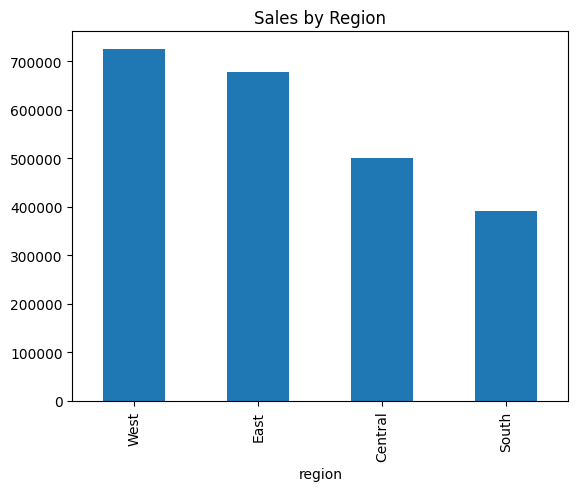

In [12]:
import matplotlib.pyplot as plt

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

In [13]:
### Regional Analysis
#- Certain regions contribute significantly more revenue.
#- High-performing regions can be targeted for expansion.

In [14]:
category_performance = df.groupby('category')[['sales', 'profit']].sum()
category_performance

,sales,profit
category,,
Furniture,741999.7784,18451.2917
Office Supplies,719047.0350,122490.8096
Technology,836154.1390,145454.9539


In [15]:
monthly_sales = df.groupby(['order_year', 'order_month'])['sales'].sum()
monthly_sales

order_year  order_month
2014        1               14236.8950
            2                4519.8920
            3               55691.0410
            4               28295.3470
            5               23648.2830
            6               34595.1230
            7               33946.3930
            8               27909.4670
            9               81777.3500
            10              31453.3870
            11              78628.7212
            12              69545.6230
2015        1               18174.0740
            2               11951.4110
            3               38726.2580
            4               34195.2110
            5               30131.6820
            6               24797.2960
            7               28765.3190
            8               36898.3370
            9               64595.9100
            10              31404.9220
            11              75972.5540
            12              74919.5130
2016        1               18542.4950
 

In [16]:
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
top_customers

customer_name
Sean Miller           25043.070
Tamara Chand          19052.168
Raymond Buch          15117.379
Tom Ashbrook          14595.652
Adrian Barton         14473.571
Ken Lonsdale          14175.231
Sanjit Chand          14142.334
Hunter Lopez          12873.328
Sanjit Engle          12209.442
Christopher Conant    12129.076
Name: sales, dtype: float64

In [17]:
df.groupby('category')['profit_margin'].mean()

category
Furniture          0.038784
Office Supplies    0.138030
Technology         0.156138
Name: profit_margin, dtype: float64

In [18]:
## 🔍 Key Business Insights

#- Revenue is concentrated in specific regions.
#- Certain product categories generate higher profits.
#- A small number of customers contribute significantly to total revenue.
#- Sales show seasonal trends across months.

## 💡 Recommendations

#- Focus marketing efforts on high-performing regions.
#- Improve margins in low-profit categories.
#- Retain high-value customers through loyalty programs.